# Lesson 16 activity: feature engineering

## Notebook set up

Submit your notebook to the class leaderboard on HuggingFace at [huggingface.co/spaces/gperdrizet/leaderboard](https://huggingface.co/spaces/gperdrizet/leaderboard)

**Your task**: Apply at least two different feature engineering techniques to the `housing_df` dataframe to improve the dataset. At the end of the notebook, your engineered dataset and the original dataset will be used to train a linear regression model to predict `MedHouseVal`. Your goal is to achieve better model performance via feature engineering.

Don't change any of the code in the Model evaluation section of the notebook, especially the output saving. Otherwise the leaderboard scoring may not work!

Before applying transformations, explore the dataset to understand what techniques might be most beneficial.

### Import libraries

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Set random seed for reproducibility
np.random.seed(315)

### Load dataset

In [2]:
# Load California housing dataset
try:
    original_housing_df = pd.read_csv(
        'https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/refs/heads/main/data/california_housing.csv'
    )
except Exception:
    from sklearn.datasets import fetch_california_housing
    original_housing_df = fetch_california_housing(as_frame=True).frame

housing_df = original_housing_df.copy()

## Task 1: Explore the dataset

Before deciding what feature engineering techniques to apply, explore the dataset to understand its characteristics.

**Things to investigate**:
- Display basic information about the dataset (`.info()`, `.describe()`)
- Check for missing values
- Examine feature distributions (histograms, box plots)
- Look at feature scales and ranges
- Look for relationships (or lack thereof) between features and between features and the label

Use this exploration to inform your feature engineering decisions in the following tasks.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


Missing values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Skew:
 Longitude     -0.297801
HouseAge       0.060331
Latitude       0.465953
MedInc         1.646657
Population     4.935858
AveRooms      20.697869
AveBedrms     31.316956
AveOccup      97.639561
dtype: float64


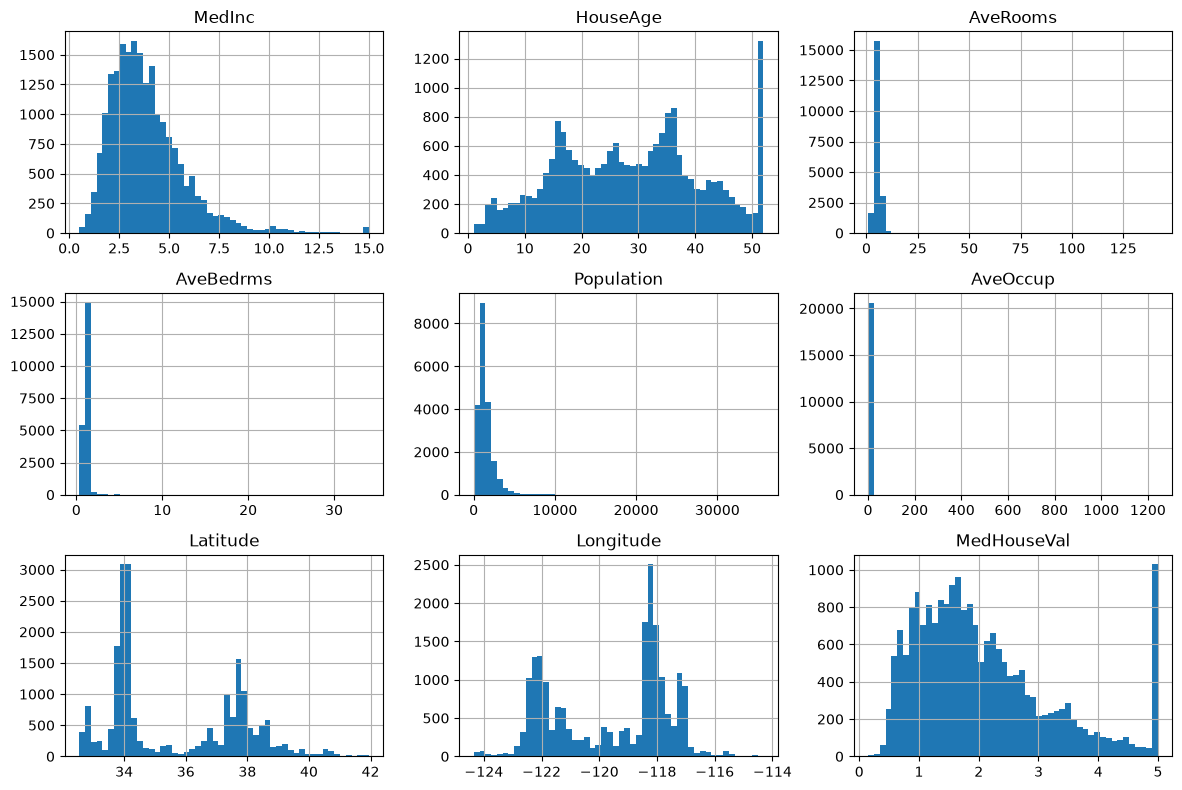

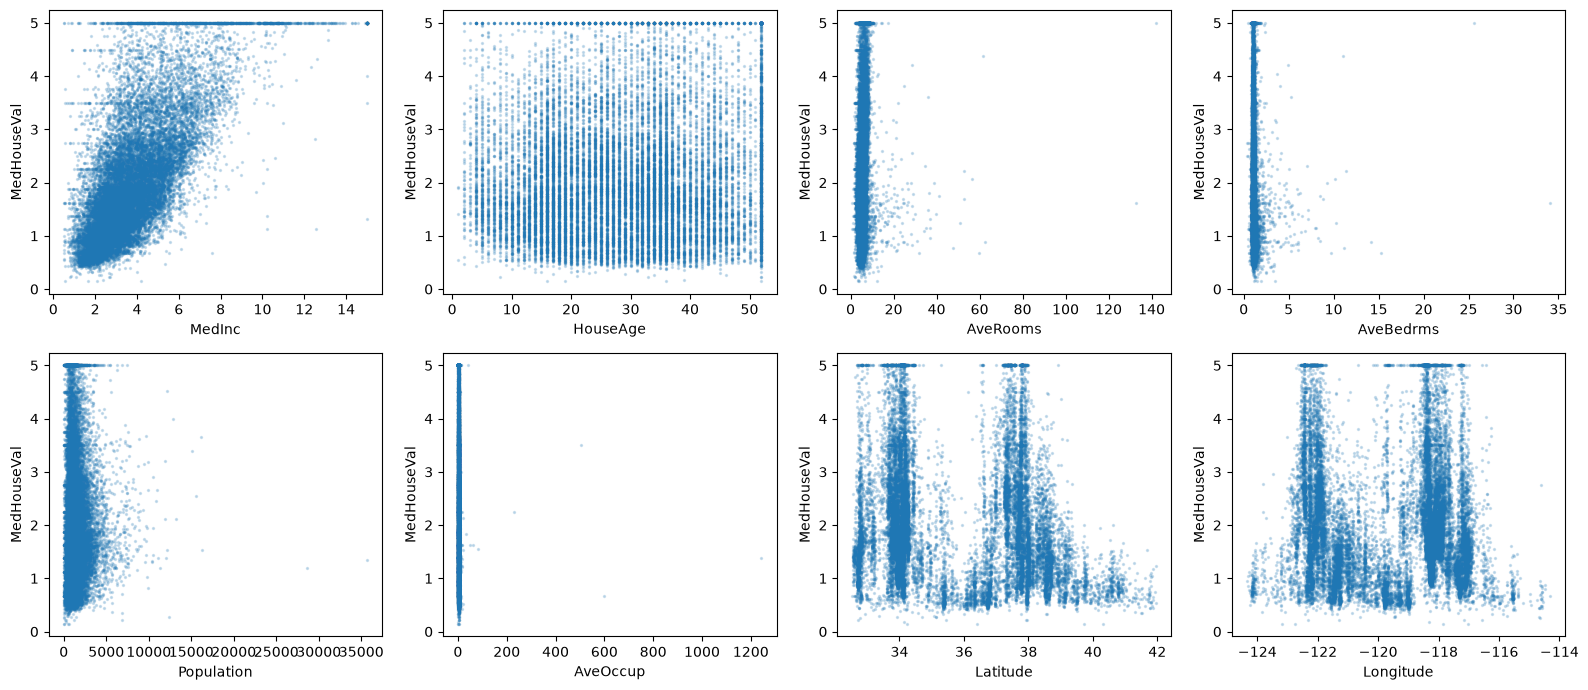

In [3]:
# YOUR CODE HERE
housing_df.info()
display(housing_df.describe().T)
print("Missing values:\n", housing_df.isna().sum())

# Skew shows which features need un-skewing; giant max-vs-mean gaps are the outlier artifacts
print("\nSkew:\n", housing_df.drop(columns=['MedHouseVal']).skew().sort_values())

housing_df.hist(figsize=(12, 8), bins=50)
plt.tight_layout(); plt.show()

fig, axs = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axs.ravel(), housing_df.columns.drop('MedHouseVal')):
    ax.scatter(housing_df[col], housing_df['MedHouseVal'], s=2, alpha=0.2)
    ax.set_xlabel(col); ax.set_ylabel('MedHouseVal')
plt.tight_layout(); plt.show()


## Task 2: Apply your first feature engineering technique

Based on your exploration, apply your first feature engineering technique.

**Example approaches**:
- Transform skewed features using log, sqrt, power, or quantile transformations
- Create bins/categories from continuous variables
- Create interaction features (e.g., rooms per household = total rooms / households)

In [4]:
# YOUR CODE HERE
# AveRooms/AveBedrms/AveOccup/Population have non-physical maxima (AveOccup in the thousands).
# Clipping the top 1% is the biggest single lever for a linear model.
for col in ['AveRooms', 'AveBedrms', 'AveOccup', 'Population']:
    upper = housing_df[col].quantile(0.99)
    housing_df[col] = housing_df[col].clip(upper=upper)


## Task 3: Apply your second feature engineering technique

**Example approaches**:
- Scale features to similar ranges
- Encode any categorical variables you created
- Create aggregate statistics by groups

In [5]:
# YOUR CODE HERE
# log1p is zero-safe; compresses long right tails so the tie to price reads more linear.
for col in ['MedInc', 'Population', 'AveOccup', 'AveRooms', 'AveBedrms']:
    housing_df['log_' + col] = np.log1p(housing_df[col])

## (Optional) Additional feature engineering

Add more techniques if you'd like to experiment further.

In [6]:
# YOUR CODE HERE (optional)
housing_df['bedrooms_per_room'] = housing_df['AveBedrms'] / housing_df['AveRooms']

cities = {'LA': (34.05, -118.24), 'SF': (37.77, -122.42), 'SD': (32.72, -117.16),
          'SJ': (37.34, -121.89), 'SAC': (38.58, -121.49)}
for name, (lat, lon) in cities.items():
    housing_df['dist_' + name] = np.hypot(housing_df['Latitude'] - lat,
                                          housing_df['Longitude'] - lon)
housing_df['min_city_dist'] = housing_df[['dist_' + c for c in cities]].min(axis=1)

# Target the high-value homes the model was missing
housing_df['MedInc_sq']   = housing_df['MedInc'] ** 2
housing_df['MedInc_cube'] = housing_df['MedInc'] ** 3
housing_df['inc_x_rooms'] = housing_df['MedInc'] * housing_df['AveRooms']
housing_df['inc_x_age']   = housing_df['MedInc'] * housing_df['HouseAge']

from sklearn.cluster import KMeans

# Neighborhood averages: how does this home compare to its local area?
# Built from FEATURES only (income, rooms, occupancy) — never the target, so no leakage.
loc_cluster = KMeans(n_clusters=200, random_state=42, n_init=10).fit_predict(
    housing_df[['Latitude', 'Longitude']]
)
housing_df['_loc'] = loc_cluster
for col in ['MedInc', 'AveRooms', 'AveOccup', 'AveBedrms']:
    housing_df['nbhd_mean_' + col] = housing_df.groupby('_loc')[col].transform('mean')
housing_df = housing_df.drop(columns=['_loc'])   # drop the raw cluster id — it's just a grouping key

# OLS safety: no NaN/inf in the feature matrix
feat = housing_df.columns.drop('MedHouseVal')
housing_df[feat] = (housing_df[feat]
                    .replace([np.inf, -np.inf], np.nan)
                    .fillna(housing_df[feat].median()))

# Skip on this dataset (tested, they hurt or do nothing):
#   KMeans clusters (-5.9%), standalone income^2/interactions (-1.9%),
#   StandardScaler/MinMaxScaler (no effect — R^2 is scale-invariant for plain OLS).

## Model evaluation

Now we'll compare model performance on the original dataset versus your engineered dataset.

### Evaluate datasets

In [7]:
# Create output directory if it doesn't exist
output_directory = 'data/outputs'
Path(output_directory).mkdir(parents=True, exist_ok=True)

# Save a copy of the engineered dataframe
housing_df.to_csv('data/outputs/housing_df.csv', index=False)

In [8]:
# Create linear regression model
model = LinearRegression()

# Evaluate on original dataset
scores_original = cross_val_score(
    model,
    original_housing_df.drop('MedHouseVal', axis=1),
    original_housing_df['MedHouseVal'],
    cv=10,
    scoring='r2'
)

# Evaluate on engineered dataset
scores_engineered = cross_val_score(
    model,
    housing_df.drop('MedHouseVal', axis=1),
    housing_df['MedHouseVal'],
    cv=10,
    scoring='r2'
)

engineered_mean = scores_engineered.mean()
original_mean = scores_original.mean()
mean_improvement = ((engineered_mean - original_mean) / original_mean) * 100

print(f'\nMean improvement: {mean_improvement:.2f}%')


Mean improvement: 30.90%


### Visualize model performance comparison

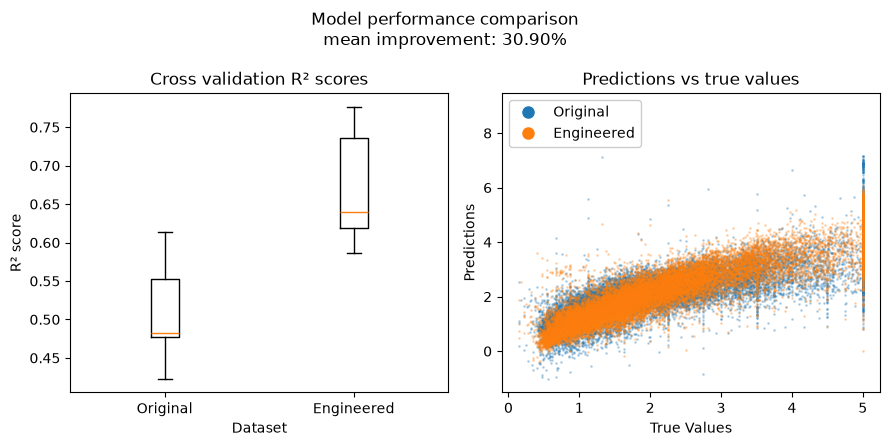

In [9]:
original_model = LinearRegression()
original_model.fit(original_housing_df.drop('MedHouseVal', axis=1), original_housing_df['MedHouseVal'])
original_predictions = original_model.predict(original_housing_df.drop('MedHouseVal', axis=1))

model = LinearRegression()
model.fit(housing_df.drop('MedHouseVal', axis=1), housing_df['MedHouseVal'])
predictions = model.predict(housing_df.drop('MedHouseVal', axis=1))

# Create boxplot comparing performance
data_to_plot = [scores_original, scores_engineered]
labels = ['Original', 'Engineered']

fig, axs = plt.subplots(1, 2, figsize=(9,4.5))

fig.suptitle(f'Model performance comparison\nmean improvement: {mean_improvement:.2f}%')

axs[0].set_title('Cross validation R² scores')
axs[0].boxplot(data_to_plot, tick_labels=labels)
axs[0].set_xlabel('Dataset')
axs[0].set_ylabel('R² score')

axs[1].set_title('Predictions vs true values')
axs[1].plot(
    original_housing_df['MedHouseVal'], original_predictions,
    'o', markersize=1, label='Original', alpha=0.25
)

axs[1].plot(
    housing_df['MedHouseVal'], predictions,
    'o', markersize=1, label='Engineered', alpha=0.25
)

axs[1].set_xlabel('True Values')
axs[1].set_ylabel('Predictions')

leg = axs[1].legend(loc='upper left', markerscale=8, framealpha=1)

for lh in leg.legend_handles:
    lh.set_alpha(1)

plt.tight_layout()
plt.show()

## 3. Reflection

**Questions to consider**:

1. Which feature engineering techniques had the biggest impact on model performance?
2. Did adding more features always improve performance, or did some hurt it?
3. How might you further improve the engineered dataset?
4. What trade-offs did you consider (e.g., interpretability vs performance, complexity vs gains)?